In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the table
models = ["GPT-2-124M", "GPT-2-124M FT", "GlassGPT-124M", "GlassGPT-124M FT", "Gemma3-240M", "OpenELM-270M", "Qwen2-0.5B"]
params = [124, 124, 124, 124, 240, 270, 500]
hellaswag = [28.92, 32.27, 32.13, 35.73, 37.7, 46.71, 49.3]
mmlu = [32.4, 32.21, 27.18, 27.05, None, 25.72, 45.4]
piqa = [62.89, 63.27, None, None, 67.7, 69.75, None]
boolq = [48.72, 50.42, 45.87, 57.28, 61.4, 53.98, 56.21]

models = ["GPT-2", "GPT-2 FT", "GlassGPT", "GlassGPT FT", "Gemma3-240M", "OpenELM-270M", "Qwen2-0.5B"]
params = [124, 124, 124, 124, 240, 270, 500]
hellaswag = [28.92, 32.27, 32.13, 35.73, 37.7, 46.71, 49.3]
mmlu = [32.4, 32.21, 27.18, 27.05, None, 25.72, 45.4]
piqa = [62.89, 63.27, 61.2, 65.1, 67.7, 69.75, None]
boolq = [48.72, 50.42, 45.87, 57.28, 61.4, 53.98, 56.21]


mmlu = [x if x is not None else np.nan for x in mmlu]
piqa = [x if x is not None else np.nan for x in piqa]


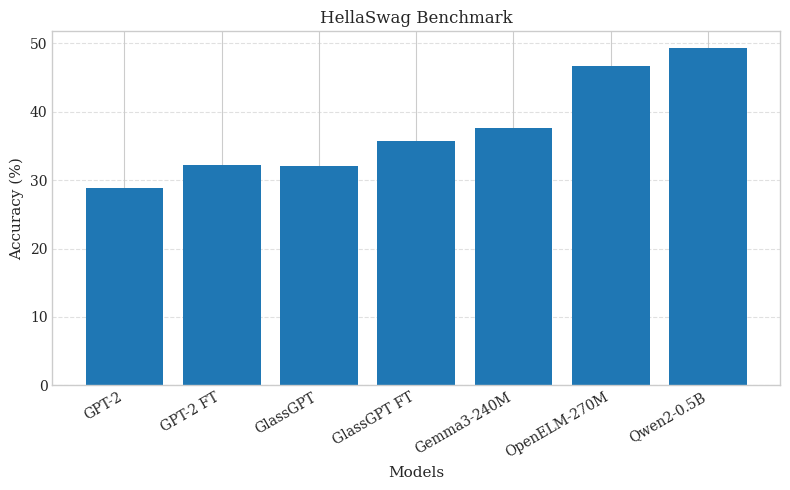

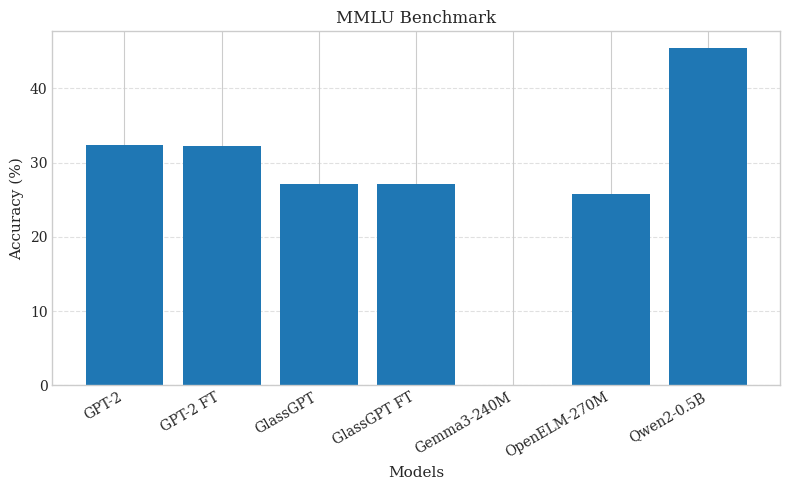

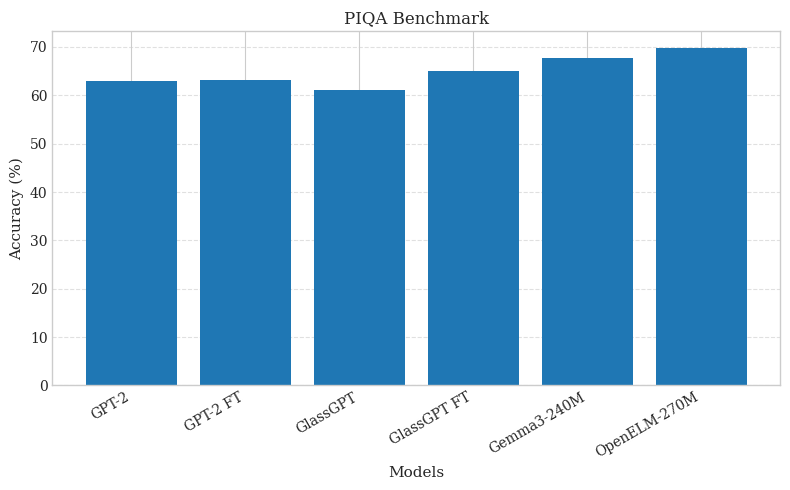

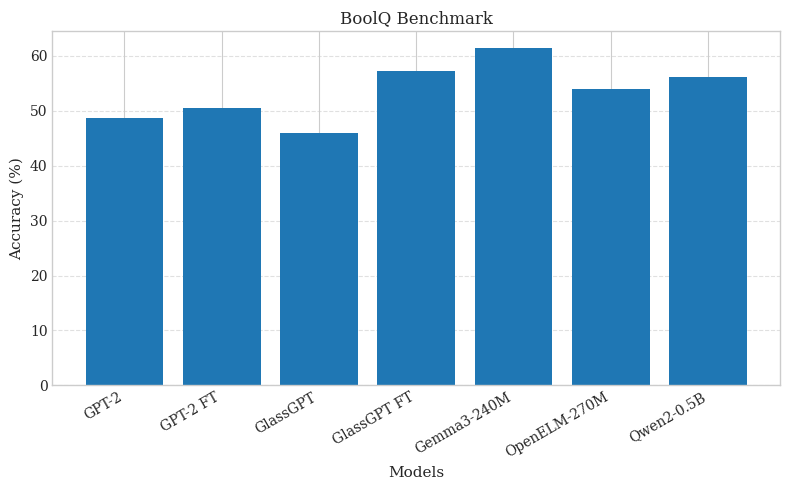

In [11]:
# Function to plot benchmarks as bar graphs
def plot_benchmark_bar(scores, title, ylabel):
    plt.figure(figsize=(8,5))
    plt.bar(models, scores)
    plt.title(title)
    plt.xlabel("Models")
    plt.ylabel(ylabel)
    plt.xticks(rotation=30, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Bar plots for each benchmark
plot_benchmark_bar(hellaswag, "HellaSwag Benchmark", "Accuracy (%)")
plot_benchmark_bar(mmlu, "MMLU Benchmark", "Accuracy (%)")
plot_benchmark_bar(piqa, "PIQA Benchmark", "Accuracy (%)")
plot_benchmark_bar(boolq, "BoolQ Benchmark", "Accuracy (%)")


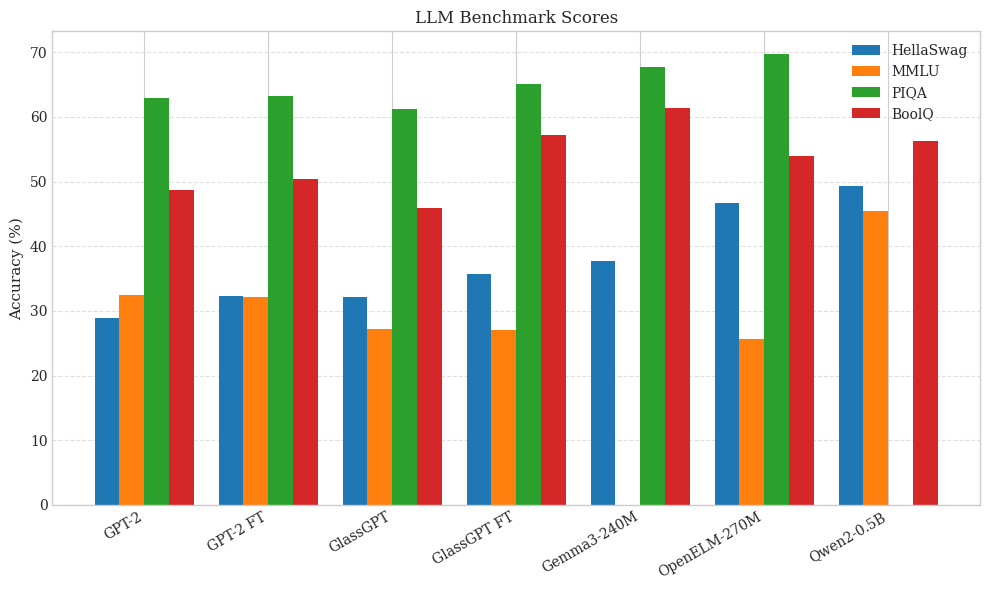

In [12]:
x = np.arange(len(models))  # model positions
width = 0.2  # bar width

plt.figure(figsize=(10,6))

plt.bar(x - 1.5*width, hellaswag, width, label="HellaSwag")
plt.bar(x - 0.5*width, mmlu, width, label="MMLU")
plt.bar(x + 0.5*width, piqa, width, label="PIQA")
plt.bar(x + 1.5*width, boolq, width, label="BoolQ")

plt.xticks(x, models, rotation=30, ha='right')
plt.ylabel("Accuracy (%)")
plt.title("LLM Benchmark Scores")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


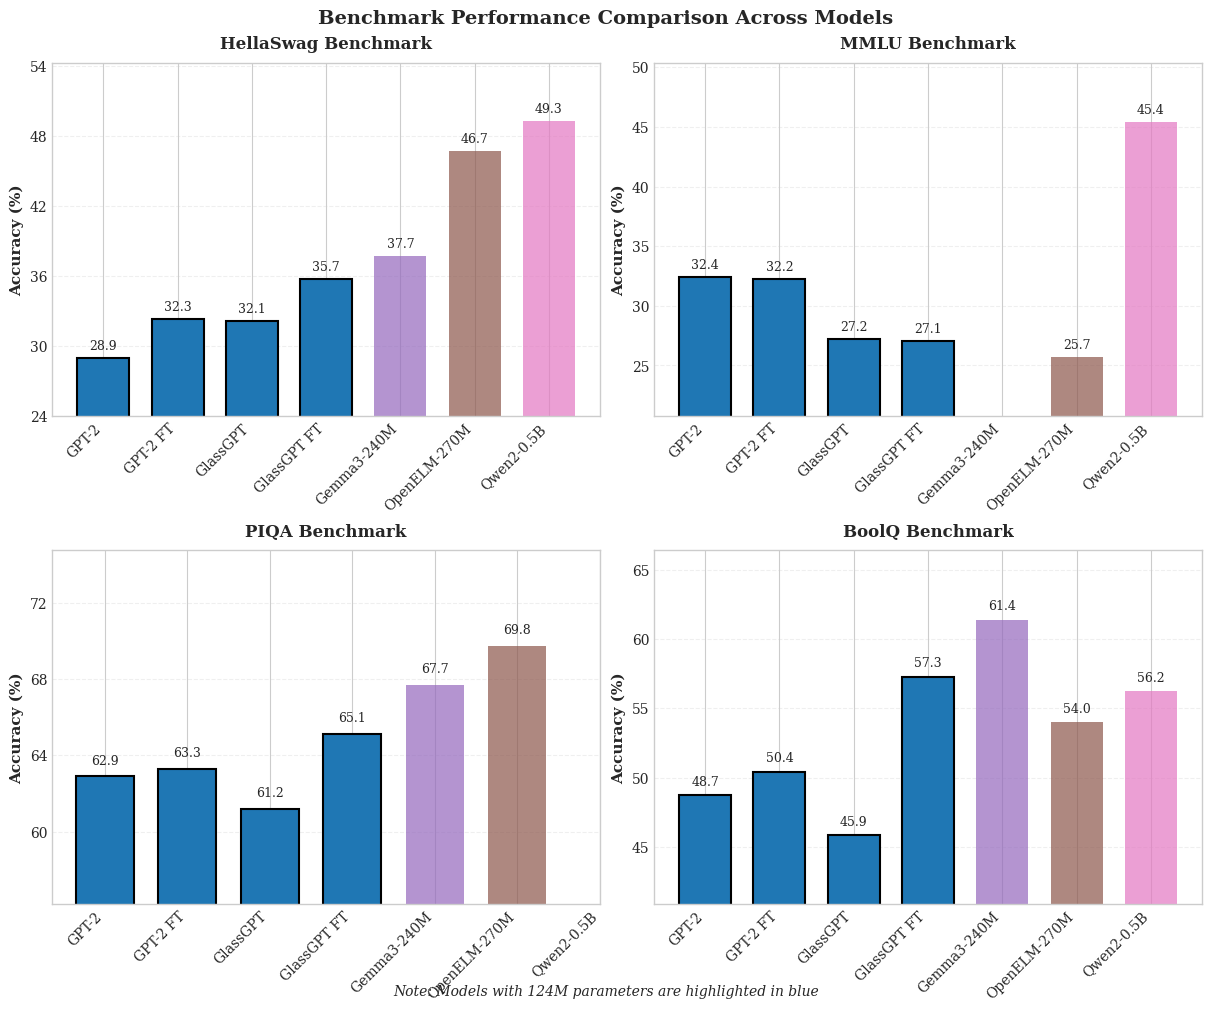

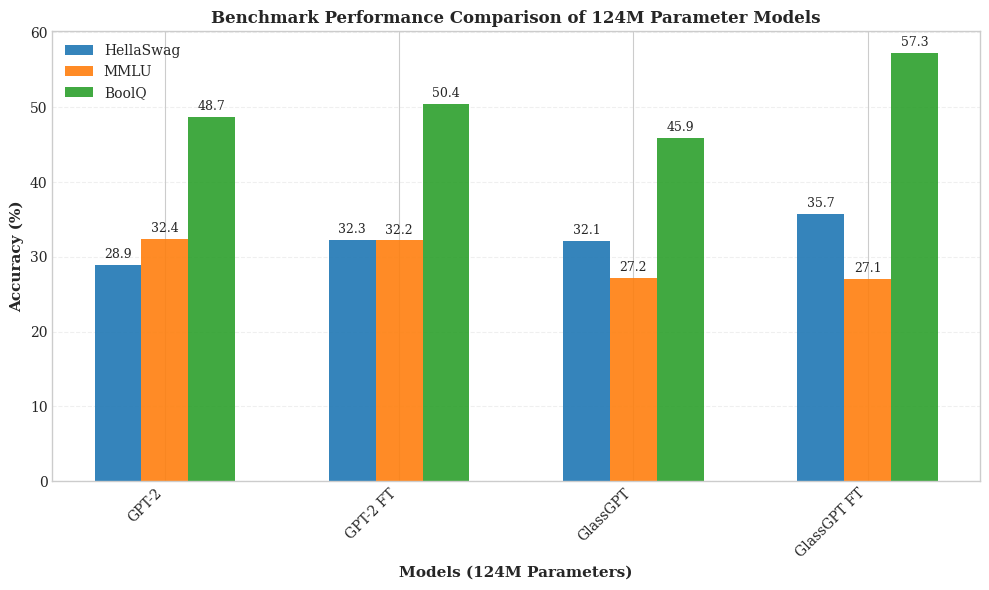

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

# Set the style for a professional publication
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
mpl.rcParams['axes.labelsize'] = 11
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
mpl.rcParams['legend.fontsize'] = 10
mpl.rcParams['figure.titlesize'] = 13

# Data from the table
models = ["GPT-2", "GPT-2 FT", "GlassGPT", "GlassGPT FT", "Gemma3-240M", "OpenELM-270M", "Qwen2-0.5B"]
params = [124, 124, 124, 124, 240, 270, 500]
hellaswag = [28.92, 32.27, 32.13, 35.73, 37.7, 46.71, 49.3]
mmlu = [32.4, 32.21, 27.18, 27.05, None, 25.72, 45.4]
piqa = [62.89, 63.27, 61.2, 65.1, 67.7, 69.75, None]
boolq = [48.72, 50.42, 45.87, 57.28, 61.4, 53.98, 56.21]

# Create a mask for models with 124M parameters
small_models_mask = np.array([p == 124 for p in params])
small_models = np.array(models)[small_models_mask]

# Prepare data
mmlu_values = np.array([x if x is not None else np.nan for x in mmlu])
piqa_values = np.array([x if x is not None else np.nan for x in piqa])
hellaswag_values = np.array(hellaswag)
boolq_values = np.array(boolq)

# Color scheme suitable for publications
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

# Function to create a single benchmark plot
def plot_benchmark(ax, values, title, highlight_mask=None):
    bars = ax.bar(range(len(models)), values, color=colors, alpha=0.7, width=0.7)
    
    # Highlight the small models if requested
    if highlight_mask is not None:
        for i, mask in enumerate(highlight_mask):
            if mask:
                bars[i].set_color('#1f77b4')
                bars[i].set_alpha(1.0)
                bars[i].set_edgecolor('black')
                bars[i].set_linewidth(1.5)
    
    # Add value labels on top of bars
    for i, bar in enumerate(bars):
        if not np.isnan(values[i]):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{values[i]:.1f}', ha='center', va='bottom', fontsize=9)
    
    # Set title and labels
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.set_ylabel('Accuracy (%)', fontweight='bold')
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    
    # Add grid for readability
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Adjust y-axis to start from a reasonable value and have some headroom
    if not np.all(np.isnan(values)):
        ymin = max(0, np.nanmin(values) - 5)
        ymax = min(100, np.nanmax(values) + 5)
        ax.set_ylim(ymin, ymax)

    return bars

# Create individual plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
axes = axes.flatten()

plot_benchmark(axes[0], hellaswag_values, "HellaSwag Benchmark", small_models_mask)
plot_benchmark(axes[1], mmlu_values, "MMLU Benchmark", small_models_mask)
plot_benchmark(axes[2], piqa_values, "PIQA Benchmark", small_models_mask)
plot_benchmark(axes[3], boolq_values, "BoolQ Benchmark", small_models_mask)

# Add a subtitle explaining the highlights
fig.suptitle('Benchmark Performance Comparison Across Models', fontsize=14, fontweight='bold')
plt.figtext(0.5, 0.01, 'Note: Models with 124M parameters are highlighted in blue', 
            ha='center', fontsize=10, fontstyle='italic')

plt.savefig('benchmark_comparison.pdf', bbox_inches='tight', dpi=300)
plt.savefig('benchmark_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

# Create a focused plot for the 124M parameter models only
plt.figure(figsize=(10, 6))
width = 0.2
x = np.arange(len(small_models))

# Only plot the small models (124M params)
hs_small = hellaswag_values[small_models_mask]
mmlu_small = mmlu_values[small_models_mask]
boolq_small = boolq_values[small_models_mask]
piqa_small = piqa_values[small_models_mask]


plt.bar(x - width, hs_small, width, label='HellaSwag', color='#1f77b4', alpha=0.9)
plt.bar(x, mmlu_small, width, label='MMLU', color='#ff7f0e', alpha=0.9)
plt.bar(x + width, boolq_small, width, label='BoolQ', color='#2ca02c', alpha=0.9)

plt.xlabel('Models (124M Parameters)', fontweight='bold')
plt.ylabel('Accuracy (%)', fontweight='bold')
plt.title('Benchmark Performance Comparison of 124M Parameter Models', fontweight='bold')
plt.xticks(x, small_models, rotation=45, ha='right')
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add value labels
for i, model in enumerate(small_models):
    plt.text(i - width, hs_small[i] + 0.5, f'{hs_small[i]:.1f}', ha='center', va='bottom', fontsize=9)
    plt.text(i, mmlu_small[i] + 0.5, f'{mmlu_small[i]:.1f}', ha='center', va='bottom', fontsize=9)
    plt.text(i + width, boolq_small[i] + 0.5, f'{boolq_small[i]:.1f}', ha='center', va='bottom', fontsize=9)


plt.tight_layout()
plt.savefig('small_models_comparison.pdf', bbox_inches='tight', dpi=300)
plt.savefig('small_models_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

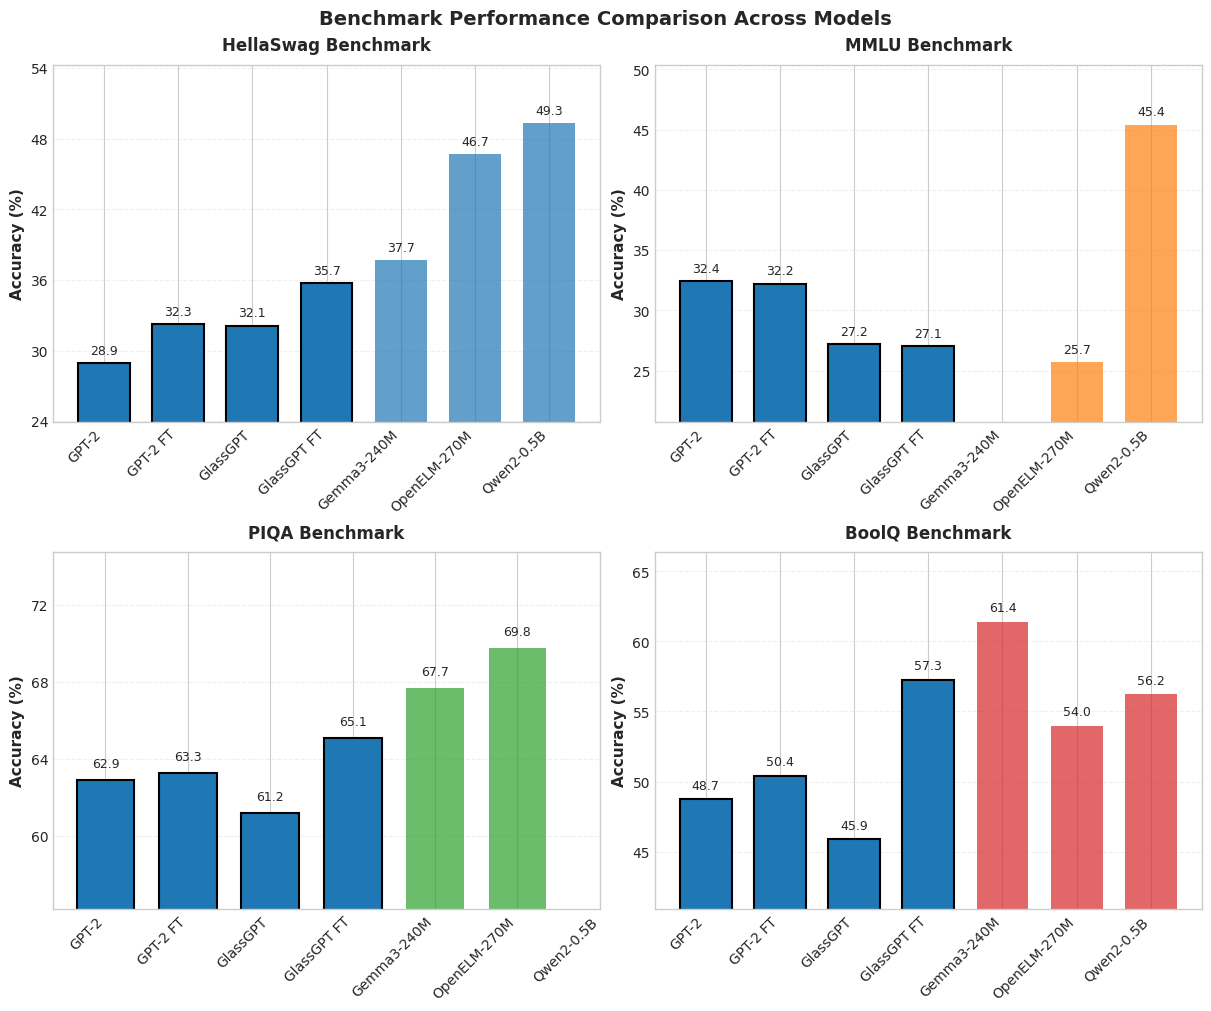

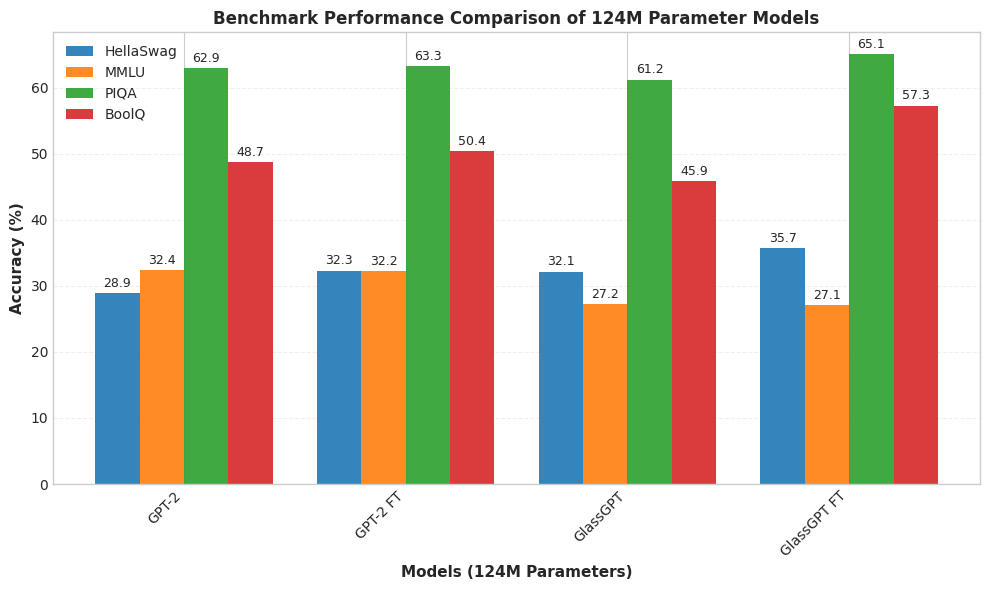

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

# ================================
# CONFIGURATION (edit here easily)
# ================================
STYLE = 'seaborn-v0_8-whitegrid'
FONT = 'Times New Roman'

# Benchmark colors
BENCHMARK_COLORS = {
    "HellaSwag": '#1f77b4',  # blue
    "MMLU": '#ff7f0e',       # orange
    "PIQA": '#2ca02c',       # green
    "BoolQ": '#d62728'       # red
}

# Highlight color for special models (124M params)
HIGHLIGHT_COLOR = '#1f77b4'

# Global font sizes
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = [FONT] + plt.rcParams['font.serif']
mpl.rcParams['axes.labelsize'] = 11
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
mpl.rcParams['legend.fontsize'] = 10
mpl.rcParams['figure.titlesize'] = 13
plt.style.use(STYLE)

# ================================
# DATA
# ================================
models = ["GPT-2", "GPT-2 FT", "GlassGPT", "GlassGPT FT", "Gemma3-240M", "OpenELM-270M", "Qwen2-0.5B"]
params = [124, 124, 124, 124, 240, 270, 500]
hellaswag = [28.92, 32.27, 32.13, 35.73, 37.7, 46.71, 49.3]
mmlu = [32.4, 32.21, 27.18, 27.05, None, 25.72, 45.4]
piqa = [62.89, 63.27, 61.2, 65.1, 67.7, 69.75, None]
boolq = [48.72, 50.42, 45.87, 57.28, 61.4, 53.98, 56.21]

# Mask for 124M models
small_models_mask = np.array([p == 124 for p in params])
small_models = np.array(models)[small_models_mask]

# Convert data with Nones → NaNs
mmlu_values = np.array([x if x is not None else np.nan for x in mmlu])
piqa_values = np.array([x if x is not None else np.nan for x in piqa])
hellaswag_values = np.array(hellaswag)
boolq_values = np.array(boolq)


# ================================
# FUNCTIONS
# ================================
def plot_benchmark(ax, values, title, highlight_mask=None, color='#1f77b4'):
    bars = ax.bar(range(len(models)), values, color=color, alpha=0.7, width=0.7)
    
    # Highlight models if requested
    if highlight_mask is not None:
        for i, mask in enumerate(highlight_mask):
            if mask:
                bars[i].set_color(HIGHLIGHT_COLOR)
                bars[i].set_alpha(1.0)
                bars[i].set_edgecolor('black')
                bars[i].set_linewidth(1.5)
    
    # Add value labels
    for i, bar in enumerate(bars):
        if not np.isnan(values[i]):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{values[i]:.1f}', ha='center', va='bottom', fontsize=9)
    
    # Style
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.set_ylabel('Accuracy (%)', fontweight='bold')
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    # Y-axis scaling
    if not np.all(np.isnan(values)):
        ymin = max(0, np.nanmin(values) - 5)
        ymax = min(100, np.nanmax(values) + 5)
        ax.set_ylim(ymin, ymax)

    return bars


# ================================
# MULTI-PANEL PLOTS
# ================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
axes = axes.flatten()

plot_benchmark(axes[0], hellaswag_values, "HellaSwag Benchmark", small_models_mask, BENCHMARK_COLORS["HellaSwag"])
plot_benchmark(axes[1], mmlu_values, "MMLU Benchmark", small_models_mask, BENCHMARK_COLORS["MMLU"])
plot_benchmark(axes[2], piqa_values, "PIQA Benchmark", small_models_mask, BENCHMARK_COLORS["PIQA"])
plot_benchmark(axes[3], boolq_values, "BoolQ Benchmark", small_models_mask, BENCHMARK_COLORS["BoolQ"])

fig.suptitle('Benchmark Performance Comparison Across Models', fontsize=14, fontweight='bold')
# plt.figtext(0.5, 0.01, 'Note: Models with 124M parameters are highlighted in blue', 
#             ha='center', fontsize=10, fontstyle='italic')

plt.savefig('benchmark_comparison.pdf', bbox_inches='tight', dpi=300)
plt.savefig('benchmark_comparison.png', bbox_inches='tight', dpi=300)
plt.show()


# ================================
# GROUPED BAR CHART (124M only)
# ================================
plt.figure(figsize=(10, 6))
width = 0.2
x = np.arange(len(small_models))

hs_small = hellaswag_values[small_models_mask]
mmlu_small = mmlu_values[small_models_mask]
piqa_small = piqa_values[small_models_mask]
boolq_small = boolq_values[small_models_mask]

plt.bar(x - 1.5*width, hs_small, width, label='HellaSwag', color=BENCHMARK_COLORS["HellaSwag"], alpha=0.9)
plt.bar(x - 0.5*width, mmlu_small, width, label='MMLU', color=BENCHMARK_COLORS["MMLU"], alpha=0.9)
plt.bar(x + 0.5*width, piqa_small, width, label='PIQA', color=BENCHMARK_COLORS["PIQA"], alpha=0.9)
plt.bar(x + 1.5*width, boolq_small, width, label='BoolQ', color=BENCHMARK_COLORS["BoolQ"], alpha=0.9)

plt.xlabel('Models (124M Parameters)', fontweight='bold')
plt.ylabel('Accuracy (%)', fontweight='bold')
plt.title('Benchmark Performance Comparison of 124M Parameter Models', fontweight='bold')
plt.xticks(x, small_models, rotation=45, ha='right')
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add value labels
for i, model in enumerate(small_models):
    plt.text(i - 1.5*width, hs_small[i] + 0.5, f'{hs_small[i]:.1f}', ha='center', va='bottom', fontsize=9)
    plt.text(i - 0.5*width, mmlu_small[i] + 0.5, f'{mmlu_small[i]:.1f}', ha='center', va='bottom', fontsize=9)
    plt.text(i + 0.5*width, piqa_small[i] + 0.5, f'{piqa_small[i]:.1f}', ha='center', va='bottom', fontsize=9)
    plt.text(i + 1.5*width, boolq_small[i] + 0.5, f'{boolq_small[i]:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('small_models_comparison.pdf', bbox_inches='tight', dpi=300)
plt.savefig('small_models_comparison.png', bbox_inches='tight', dpi=300)
plt.show()


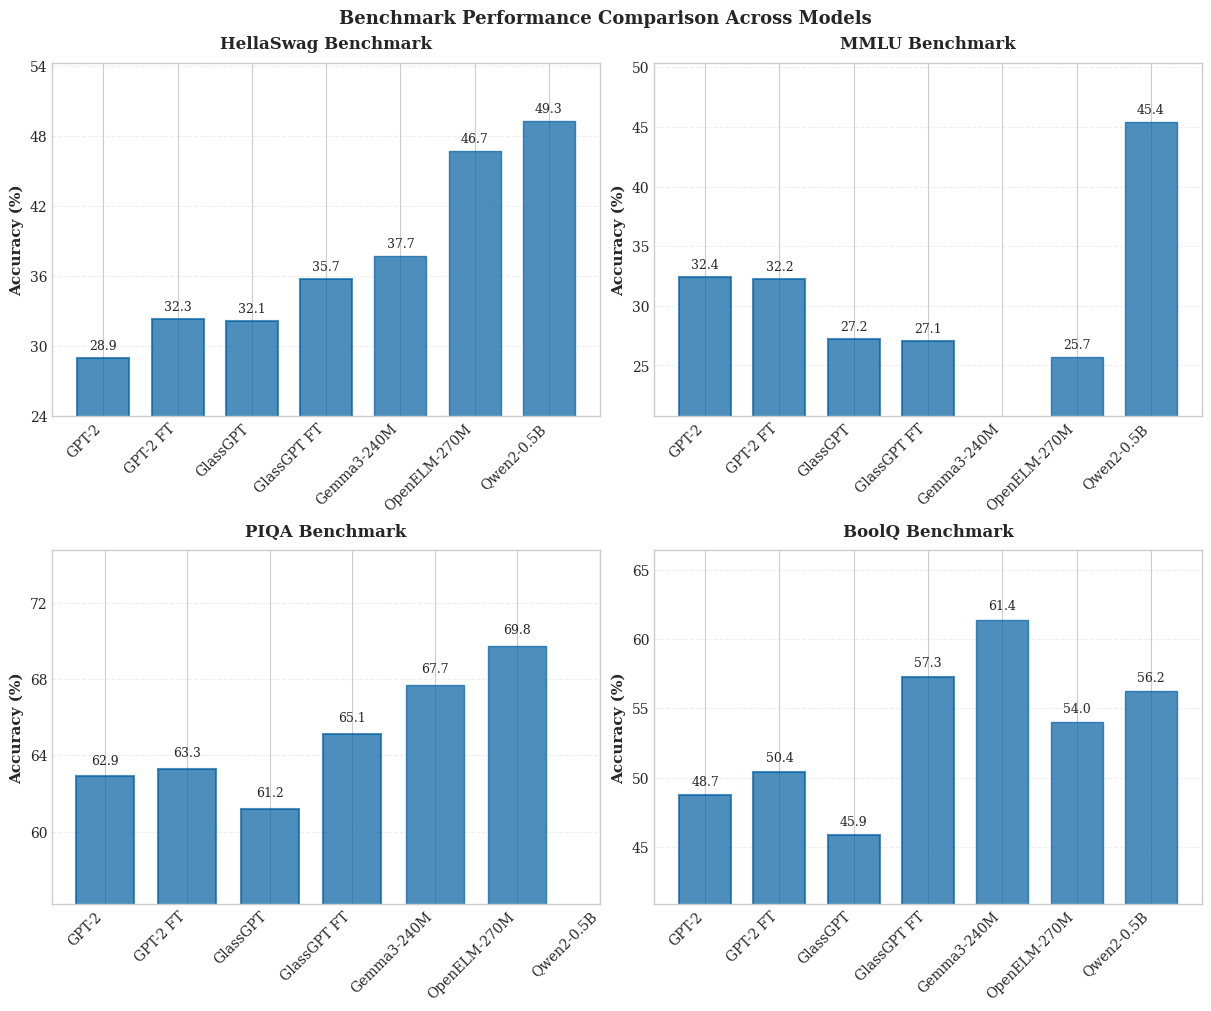

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

# ------------------- #
# --- CONFIGURATION --- #
# ------------------- #
# Easily edit and adjust colors and styles here
config = {
    'style': STYLE,
    'font_family': STYLE_CONFIG['font_family'],
    'font_serif': FONT,
    'font_sizes': {
        'axes_labels': STYLE_CONFIG['axes_labelsize'],
        'axes_title': STYLE_CONFIG['axes_titlesize'],
        'xtick_labels': STYLE_CONFIG['xtick_labelsize'],
        'ytick_labels': STYLE_CONFIG['ytick_labelsize'],
        'legend': STYLE_CONFIG['legend_fontsize'],
        'figure_title': STYLE_CONFIG['figure_titlesize'],
        'bar_labels': STYLE_CONFIG['value_label_fontsize'],
    },
    # All benchmarks use the same blue color
    'benchmark_colors': {
        'HellaSwag': '#1f77b4',
        'MMLU': '#1f77b4',
        'PIQA': '#1f77b4',
        'BoolQ': '#1f77b4',
    },
    # All models use the same blue color
    'model_colors': ['#1f77b4'] * len(models),
    'highlight_color': '#1f77b4'
}

# --- Apply Styles from Config --- #
plt.style.use(config['style'])
mpl.rcParams['font.family'] = config['font_family']
mpl.rcParams['font.serif'] = [config['font_serif']] + plt.rcParams['font.serif']
mpl.rcParams['axes.labelsize'] = config['font_sizes']['axes_labels']
mpl.rcParams['axes.titlesize'] = config['font_sizes']['axes_title']
mpl.rcParams['xtick.labelsize'] = config['font_sizes']['xtick_labels']
mpl.rcParams['ytick.labelsize'] = config['font_sizes']['ytick_labels']
mpl.rcParams['legend.fontsize'] = config['font_sizes']['legend']
mpl.rcParams['figure.titlesize'] = config['font_sizes']['figure_title']

# --- Data from the table --- #
models = ["GPT-2", "GPT-2 FT", "GlassGPT", "GlassGPT FT", "Gemma3-240M", "OpenELM-270M", "Qwen2-0.5B"]
params = [124, 124, 124, 124, 240, 270, 500]
hellaswag = [28.92, 32.27, 32.13, 35.73, 37.7, 46.71, 49.3]
mmlu = [32.4, 32.21, 27.18, 27.05, None, 25.72, 45.4]
piqa = [62.89, 63.27, 61.2, 65.1, 67.7, 69.75, None]
boolq = [48.72, 50.42, 45.87, 57.28, 61.4, 53.98, 56.21]

# Create a mask for models with 124M parameters
small_models_mask = np.array([p == 124 for p in params])
small_models = np.array(models)[small_models_mask]

# Prepare data
mmlu_values = np.array([x if x is not None else np.nan for x in mmlu])
piqa_values = np.array([x if x is not None else np.nan for x in piqa])
hellaswag_values = np.array(hellaswag)
boolq_values = np.array(boolq)

# --- Plotting Functions --- #
def plot_benchmark(ax, values, title, highlight_mask=None):
    """Function to create a single benchmark plot."""
    bars = ax.bar(range(len(models)), values, color=config['model_colors'], alpha=0.7, width=0.7)
    
    # Highlight the small models if requested
    if highlight_mask is not None:
        for i, mask in enumerate(highlight_mask):
            if mask:
                bars[i].set_color(config['highlight_color'])
                bars[i].set_alpha(1.0)
                bars[i].set_edgecolor('black')
                bars[i].set_linewidth(1.5)
    
    # Add value labels on top of bars
    for i, bar in enumerate(bars):
        if not np.isnan(values[i]):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{values[i]:.1f}', ha='center', va='bottom', fontsize=config['font_sizes']['bar_labels'])
    # Ensure consistent blue color for all bars
    for bar in bars:
        bar.set_color("#015fa2")
        bar.set_alpha(0.7)
    # Set title and labels
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.set_ylabel('Accuracy (%)', fontweight='bold')
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    
    # Add grid for readability
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Adjust y-axis
    if not np.all(np.isnan(values)):
        ymin = max(0, np.nanmin(values) - 5)
        ymax = min(100, np.nanmax(values) + 5)
        ax.set_ylim(ymin, ymax)

    return bars

# --- PLOT 1: Individual Benchmark Plots --- #
fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
axes = axes.flatten()

plot_benchmark(axes[0], hellaswag_values, "HellaSwag Benchmark", small_models_mask)
plot_benchmark(axes[1], mmlu_values, "MMLU Benchmark", small_models_mask)
plot_benchmark(axes[2], piqa_values, "PIQA Benchmark", small_models_mask)
plot_benchmark(axes[3], boolq_values, "BoolQ Benchmark", small_models_mask)

fig.suptitle('Benchmark Performance Comparison Across Models', fontsize=config['font_sizes']['figure_title'], fontweight='bold')
# plt.figtext(0.5, 0.01, f"Note: Models with 124M parameters are highlighted in blue", 
            # ha='center', fontsize=config['font_sizes']['xtick_labels'], fontstyle='italic')

plt.savefig('benchmark_comparison.pdf', bbox_inches='tight', dpi=300)
plt.savefig('benchmark_comparison.png', bbox_inches='tight', dpi=300)
plt.show()


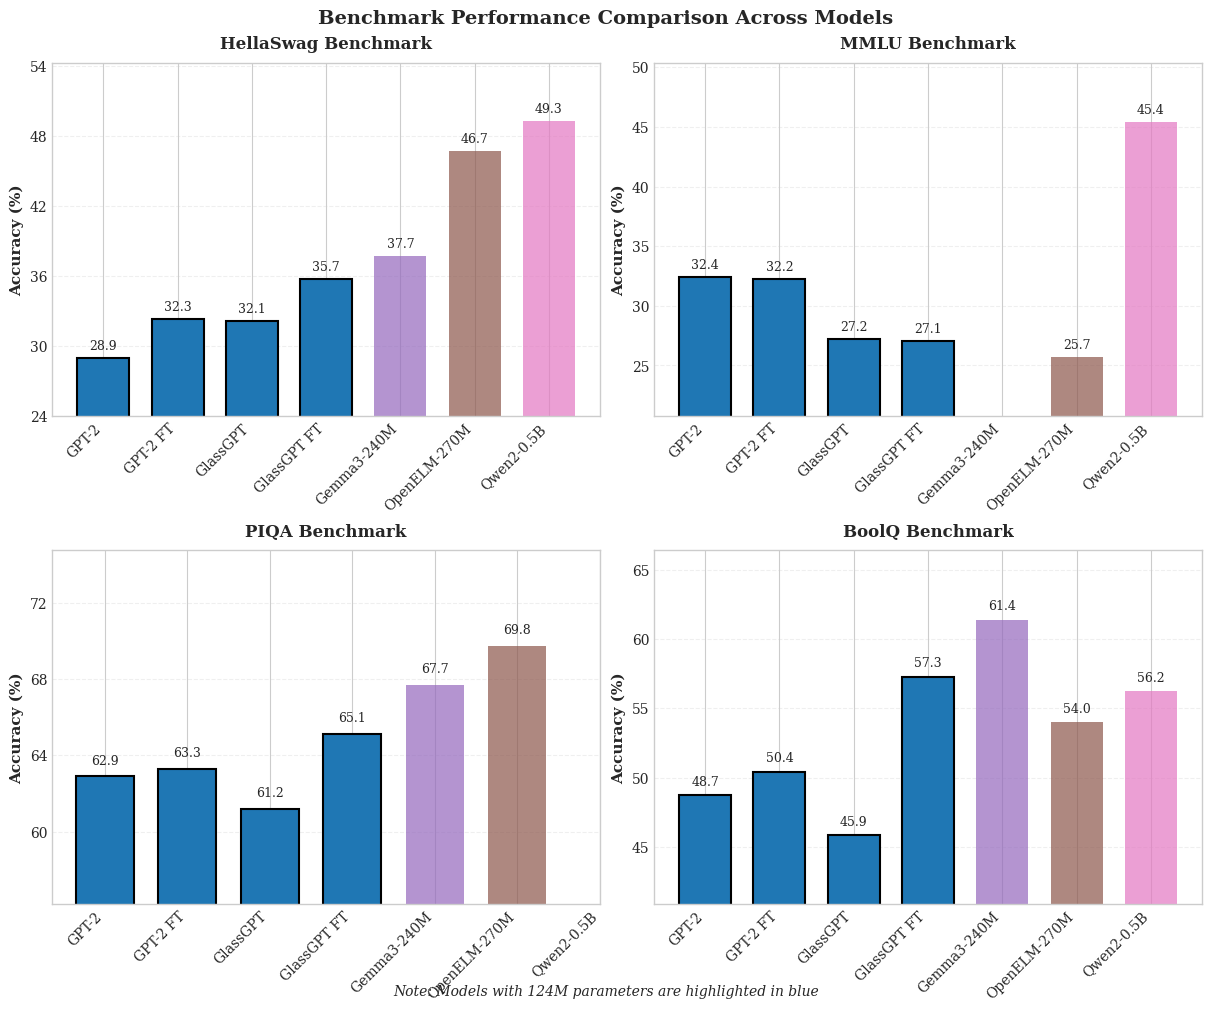

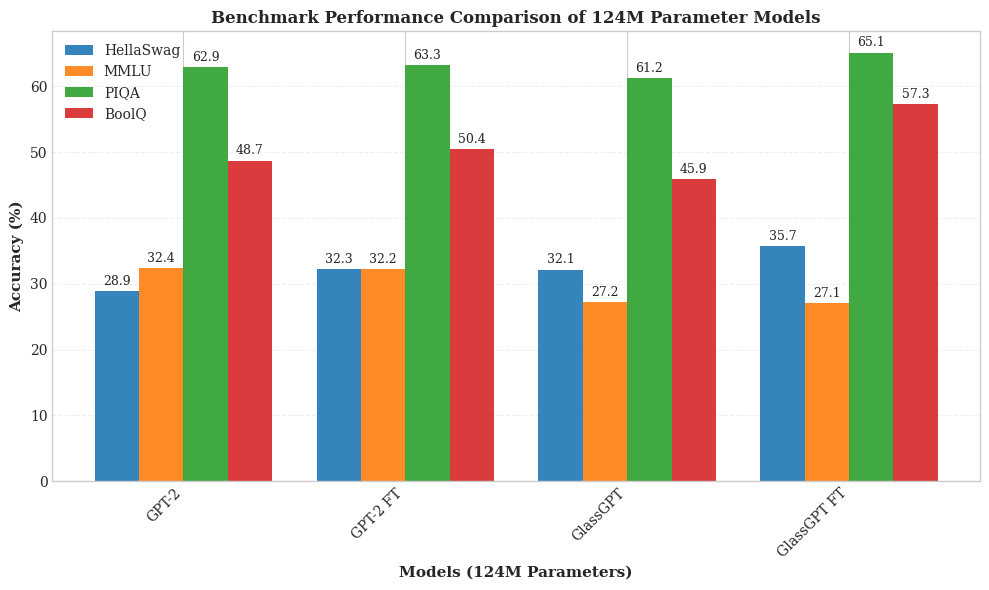

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

# ============= CONFIGURATION SECTION =============
# Colors for different benchmarks and models
COLOR_CONFIG = {
    'hellaswag': '#1f77b4',  # Blue
    'mmlu': '#ff7f0e',       # Orange
    'piqa': '#2ca02c',       # Green
    'boolq': '#d62728',      # Red
    
    # Colors for different models
    'model_colors': ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2'],
    
    # Highlight color for 124M models
    'highlight_color': '#1f77b4',
    'highlight_edge_color': 'black',
    'highlight_linewidth': 1.5,
    'highlight_alpha': 1.0,
    
    # Regular model styling
    'regular_alpha': 0.7,
}

# Font and style configuration
STYLE_CONFIG = {
    'font_family': 'serif',
    'font_serif': ['Times New Roman'],
    'axes_labelsize': 11,
    'axes_titlesize': 12,
    'xtick_labelsize': 10,
    'ytick_labelsize': 10,
    'legend_fontsize': 10,
    'figure_titlesize': 13,
    'bar_width': 0.7,
    'small_model_bar_width': 0.2,
    'value_label_fontsize': 9,
    'title_fontweight': 'bold',
    'title_pad': 10,
}

# Plot layout configuration
LAYOUT_CONFIG = {
    'full_comparison_figsize': (12, 10),
    'small_models_figsize': (10, 6),
    'dpi': 300,
    'constrained_layout': True,
    'grid_alpha': 0.3,
}

# Data configuration
DATA_CONFIG = {
    'ymin_offset': 5,  # How much to extend below minimum value
    'ymax_offset': 5,  # How much to extend above maximum value
}

# Output file configuration
OUTPUT_CONFIG = {
    'full_comparison_pdf': 'benchmark_comparison.pdf',
    'full_comparison_png': 'benchmark_comparison.png',
    'small_models_pdf': 'small_models_comparison.pdf',
    'small_models_png': 'small_models_comparison.png',
}
# =============== END CONFIG SECTION ===============

# Apply style configuration
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = STYLE_CONFIG['font_family']
mpl.rcParams['font.serif'] = STYLE_CONFIG['font_serif'] + plt.rcParams['font.serif']
mpl.rcParams['axes.labelsize'] = STYLE_CONFIG['axes_labelsize']
mpl.rcParams['axes.titlesize'] = STYLE_CONFIG['axes_titlesize']
mpl.rcParams['xtick.labelsize'] = STYLE_CONFIG['xtick_labelsize']
mpl.rcParams['ytick.labelsize'] = STYLE_CONFIG['ytick_labelsize']
mpl.rcParams['legend.fontsize'] = STYLE_CONFIG['legend_fontsize']
mpl.rcParams['figure.titlesize'] = STYLE_CONFIG['figure_titlesize']

# Data from the table
models = ["GPT-2", "GPT-2 FT", "GlassGPT", "GlassGPT FT", "Gemma3-240M", "OpenELM-270M", "Qwen2-0.5B"]
params = [124, 124, 124, 124, 240, 270, 500]
hellaswag = [28.92, 32.27, 32.13, 35.73, 37.7, 46.71, 49.3]
mmlu = [32.4, 32.21, 27.18, 27.05, None, 25.72, 45.4]
piqa = [62.89, 63.27, 61.2, 65.1, 67.7, 69.75, None]
boolq = [48.72, 50.42, 45.87, 57.28, 61.4, 53.98, 56.21]

# Create a mask for models with 124M parameters
small_models_mask = np.array([p == 124 for p in params])
small_models = np.array(models)[small_models_mask]

# Prepare data
mmlu_values = np.array([x if x is not None else np.nan for x in mmlu])
piqa_values = np.array([x if x is not None else np.nan for x in piqa])
hellaswag_values = np.array(hellaswag)
boolq_values = np.array(boolq)

# Function to create a single benchmark plot
def plot_benchmark(ax, values, title, highlight_mask=None):
    bars = ax.bar(range(len(models)), values, 
                  color=COLOR_CONFIG['model_colors'], 
                  alpha=COLOR_CONFIG['regular_alpha'], 
                  width=STYLE_CONFIG['bar_width'])
    
    # Highlight the small models if requested
    if highlight_mask is not None:
        for i, mask in enumerate(highlight_mask):
            if mask:
                bars[i].set_color(COLOR_CONFIG['highlight_color'])
                bars[i].set_alpha(COLOR_CONFIG['highlight_alpha'])
                bars[i].set_edgecolor(COLOR_CONFIG['highlight_edge_color'])
                bars[i].set_linewidth(COLOR_CONFIG['highlight_linewidth'])
    
    # Add value labels on top of bars
    for i, bar in enumerate(bars):
        if not np.isnan(values[i]):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{values[i]:.1f}', 
                    ha='center', va='bottom', 
                    fontsize=STYLE_CONFIG['value_label_fontsize'])
    
    # Set title and labels
    ax.set_title(title, fontweight=STYLE_CONFIG['title_fontweight'], pad=STYLE_CONFIG['title_pad'])
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.set_ylabel('Accuracy (%)', fontweight=STYLE_CONFIG['title_fontweight'])
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    
    # Add grid for readability
    ax.grid(axis='y', linestyle='--', alpha=LAYOUT_CONFIG['grid_alpha'])
    
    # Adjust y-axis to start from a reasonable value and have some headroom
    if not np.all(np.isnan(values)):
        ymin = max(0, np.nanmin(values) - DATA_CONFIG['ymin_offset'])
        ymax = min(100, np.nanmax(values) + DATA_CONFIG['ymax_offset'])
        ax.set_ylim(ymin, ymax)

    return bars

# Create individual plots
fig, axes = plt.subplots(2, 2, 
                        figsize=LAYOUT_CONFIG['full_comparison_figsize'], 
                        constrained_layout=LAYOUT_CONFIG['constrained_layout'])
axes = axes.flatten()

plot_benchmark(axes[0], hellaswag_values, "HellaSwag Benchmark", small_models_mask)
plot_benchmark(axes[1], mmlu_values, "MMLU Benchmark", small_models_mask)
plot_benchmark(axes[2], piqa_values, "PIQA Benchmark", small_models_mask)
plot_benchmark(axes[3], boolq_values, "BoolQ Benchmark", small_models_mask)

# Add a subtitle explaining the highlights
fig.suptitle('Benchmark Performance Comparison Across Models', fontsize=14, fontweight='bold')
plt.figtext(0.5, 0.01, 'Note: Models with 124M parameters are highlighted in blue', 
            ha='center', fontsize=10, fontstyle='italic')

plt.savefig(OUTPUT_CONFIG['full_comparison_pdf'], bbox_inches='tight', dpi=LAYOUT_CONFIG['dpi'])
plt.savefig(OUTPUT_CONFIG['full_comparison_png'], bbox_inches='tight', dpi=LAYOUT_CONFIG['dpi'])
plt.show()

# Create a focused plot for the 124M parameter models only
plt.figure(figsize=LAYOUT_CONFIG['small_models_figsize'])
width = STYLE_CONFIG['small_model_bar_width']
x = np.arange(len(small_models))

# Only plot the small models (124M params)
hs_small = hellaswag_values[small_models_mask]
mmlu_small = mmlu_values[small_models_mask]
boolq_small = boolq_values[small_models_mask]
piqa_small = piqa_values[small_models_mask]

# Now include all 4 benchmarks
plt.bar(x - 1.5*width, hs_small, width, label='HellaSwag', color=COLOR_CONFIG['hellaswag'], alpha=0.9)
plt.bar(x - 0.5*width, mmlu_small, width, label='MMLU', color=COLOR_CONFIG['mmlu'], alpha=0.9)
plt.bar(x + 0.5*width, piqa_small, width, label='PIQA', color=COLOR_CONFIG['piqa'], alpha=0.9)
plt.bar(x + 1.5*width, boolq_small, width, label='BoolQ', color=COLOR_CONFIG['boolq'], alpha=0.9)

plt.xlabel('Models (124M Parameters)', fontweight='bold')
plt.ylabel('Accuracy (%)', fontweight='bold')
plt.title('Benchmark Performance Comparison of 124M Parameter Models', fontweight='bold')
plt.xticks(x, small_models, rotation=45, ha='right')
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=LAYOUT_CONFIG['grid_alpha'])

# Add value labels for all 4 benchmarks
for i, model in enumerate(small_models):
    plt.text(i - 1.5*width, hs_small[i] + 0.5, f'{hs_small[i]:.1f}', ha='center', va='bottom', fontsize=STYLE_CONFIG['value_label_fontsize'])
    plt.text(i - 0.5*width, mmlu_small[i] + 0.5, f'{mmlu_small[i]:.1f}', ha='center', va='bottom', fontsize=STYLE_CONFIG['value_label_fontsize'])
    plt.text(i + 0.5*width, piqa_small[i] + 0.5, f'{piqa_small[i]:.1f}', ha='center', va='bottom', fontsize=STYLE_CONFIG['value_label_fontsize'])
    plt.text(i + 1.5*width, boolq_small[i] + 0.5, f'{boolq_small[i]:.1f}', ha='center', va='bottom', fontsize=STYLE_CONFIG['value_label_fontsize'])

plt.tight_layout()
plt.savefig(OUTPUT_CONFIG['small_models_pdf'], bbox_inches='tight', dpi=LAYOUT_CONFIG['dpi'])
plt.savefig(OUTPUT_CONFIG['small_models_png'], bbox_inches='tight', dpi=LAYOUT_CONFIG['dpi'])
plt.show()